# Toy distribution sanity check
Loads a trained checkpoint, runs the reverse SDE, and compares the generated samples
against a reference distribution to verify the model has actually learned something.

In [48]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
CHECKPOINT_PATH       = "../checkpoints/toy/NO_TOY_STUDENTT_UNCO_ep-300_step-900_sde-ve_noise-exponential_lr-1e-04_N-2000_notlinear_layers-4_nheads-8_20260401_185341.pt"
REFERENCE_DISTRIBUTION = "student_t"   # "gaussian" | "student_t"

# Reference distribution parameters — must match how the toy CSV was generated
REF_STD = 1   # std for Gaussian; also sets the scale for Student-t
REF_DF  = 4      # degrees of freedom (Student-t only)

N_SAMPLES  = 256   # how many sequences to generate
N_STEPS    = 2000   # reverse SDE steps (None = use model config default)
SEED       = 0
# ─────────────────────────────────────────────────────────────────────────────

In [42]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

from src.models.model_core import CSDIModel
from src.utils.WIP_processes import Diffusion_Processes

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load checkpoint and instantiate model

In [43]:
ckpt   = torch.load(CHECKPOINT_PATH, map_location=device)
config = ckpt["config"]

target_dim = int(config["data"]["target_dim"])
seq_len    = int(config["train"]["seq_len"])

processes = Diffusion_Processes(config["process"])

model = CSDIModel(target_dim=target_dim, config=config, device=device).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"Checkpoint epoch : {ckpt.get('epoch', '?')}")
print(f"target_dim={target_dim}  seq_len={seq_len}")
print(f"SDE: {config['process']['sde_type']}  "
      f"sigma_min={config['process']['sigma_min']}  "
      f"sigma_max={config['process']['sigma_max']}")

print("Config:\n", config)

Checkpoint epoch : 299
target_dim=1  seq_len=64
SDE: ve  sigma_min=0.1  sigma_max=10.0
Config:
 {'data': {'target_dim': 1}, 'model': {'timeemb': 256, 'featureemb': 64, 'is_unconditional': True}, 'diffusion': {'num_steps': 200, 'diffusion_embedding_dim': 256, 'channels': 128, 'layers': 4, 'nheads': 8, 'is_linear': False}, 'process': {'N': 2000, 'sde_type': 've', 'noise_schedule': 'exponential', 'sigma_min': 0.1, 'sigma_max': 10.0, 'beta_min': 0.01, 'beta_max': 5.0, 'model_steps': 200, 'eps': 0.001, 'enforce_observed': True}, 'train': {'seed': 42, 'epochs': 300, 'batch_size': 64, 'lr': 0.0001, 'weight_decay': 0.0001, 'use_amp': False, 'mask_mode': 'unconditional', 'cond_min_ratio': 0.1, 'cond_max_ratio': 0.9, 'ema_beta': 0.98, 'log_every_steps': 50, 'save_every_steps': 1000, 'seq_len': 64, 'stride': 64, 'num_workers': 4, 'shuffle': True, 'pin_memory': False, 'out_dir': './checkpoints/replication', 'data_root': './data/toy_studentt', 'early_stop_patience': 50, 'train_subset_ratio': 1.0, '

c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## 2. Run reverse SDE (unconditional generation)

This is our SDE: <src.utils.WIP_SDE.VESDE object at 0x000001FA3E4039E0>
This is the value of T: 1.0
Check prior ve: Mean = 0.005413886159658432, Std = 10.0615234375
[step    1/2000 | t=1.0000]  mean=0.0043  std=10.0126  min=-37.9363  max=41.8955  dx_norm=3.83e-04
  skew=-0.0128  kurt(excess)=-0.0325
  per-feat std: k0=10.013
  elapsed 0.7s



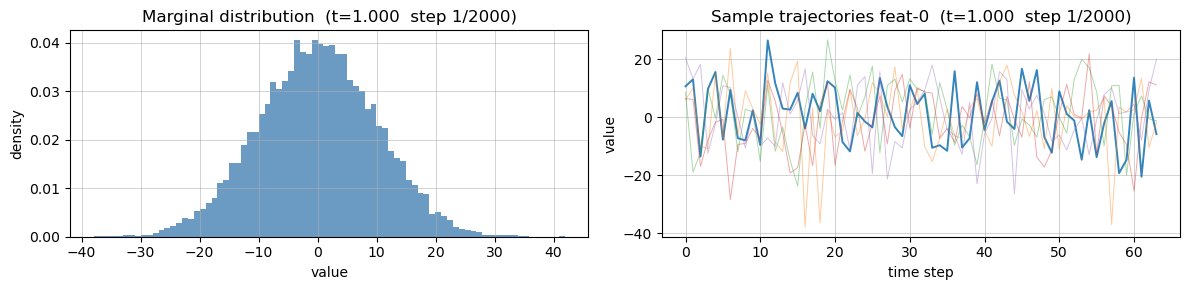

[step  201/2000 | t=0.9001]  mean=-0.0376  std=6.3513  min=-24.9366  max=37.4638  dx_norm=3.37e-03
  skew=0.0330  kurt(excess)=0.1751
  per-feat std: k0=6.351
  elapsed 136.6s



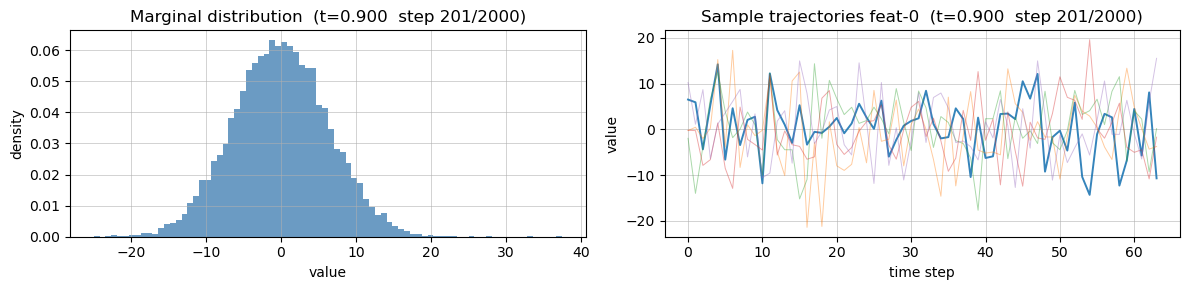

[step  401/2000 | t=0.8001]  mean=-0.0953  std=4.1379  min=-19.2271  max=23.4590  dx_norm=2.12e-03
  skew=-0.0024  kurt(excess)=0.2755
  per-feat std: k0=4.138
  elapsed 137.3s



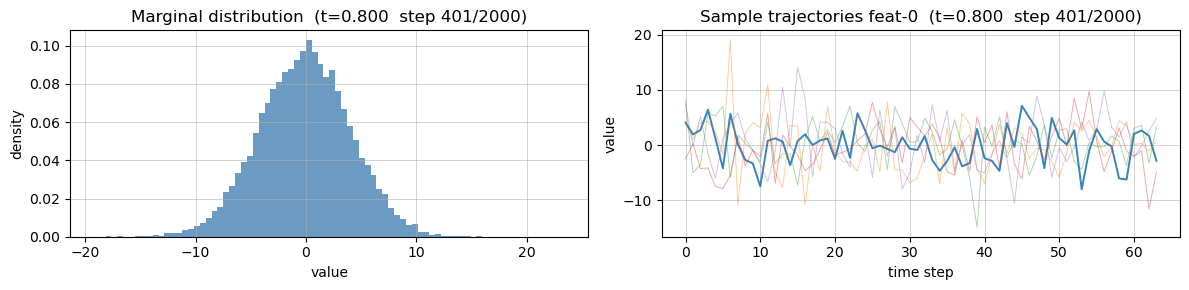

[step  601/2000 | t=0.7002]  mean=-0.1134  std=2.7406  min=-14.9284  max=16.4372  dx_norm=1.33e-03
  skew=-0.0161  kurt(excess)=0.3929
  per-feat std: k0=2.741
  elapsed 137.1s



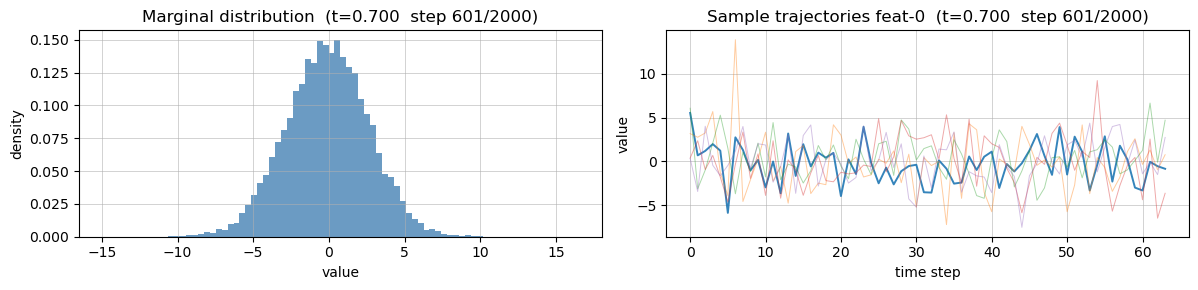

[step  801/2000 | t=0.6002]  mean=-0.0978  std=1.9021  min=-10.0998  max=11.8978  dx_norm=8.42e-04
  skew=-0.0104  kurt(excess)=0.6954
  per-feat std: k0=1.902
  elapsed 136.4s



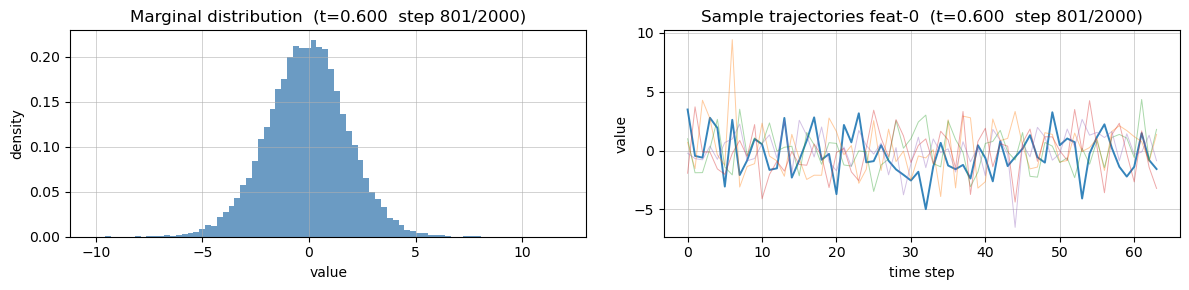

[step 1001/2000 | t=0.5003]  mean=-0.0790  std=1.4196  min=-10.1607  max=9.4791  dx_norm=5.29e-04
  skew=0.0194  kurt(excess)=1.1964
  per-feat std: k0=1.420
  elapsed 138.0s



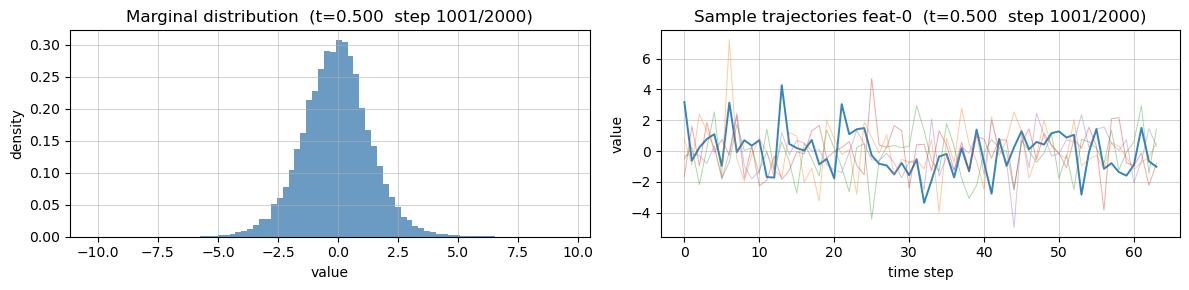

[step 1201/2000 | t=0.4003]  mean=-0.0668  std=1.1776  min=-9.1751  max=8.2794  dx_norm=3.33e-04
  skew=-0.0082  kurt(excess)=1.8713
  per-feat std: k0=1.178
  elapsed 138.8s



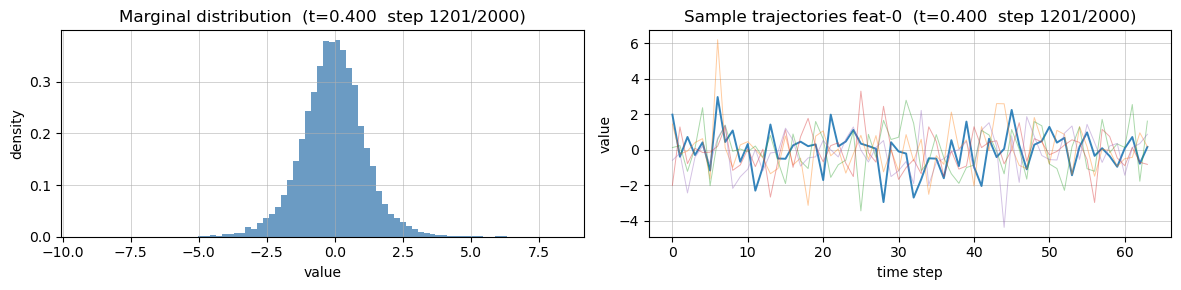

[step 1401/2000 | t=0.3004]  mean=-0.0666  std=1.0708  min=-8.8410  max=7.8164  dx_norm=2.14e-04
  skew=-0.0009  kurt(excess)=2.4560
  per-feat std: k0=1.071
  elapsed 136.3s



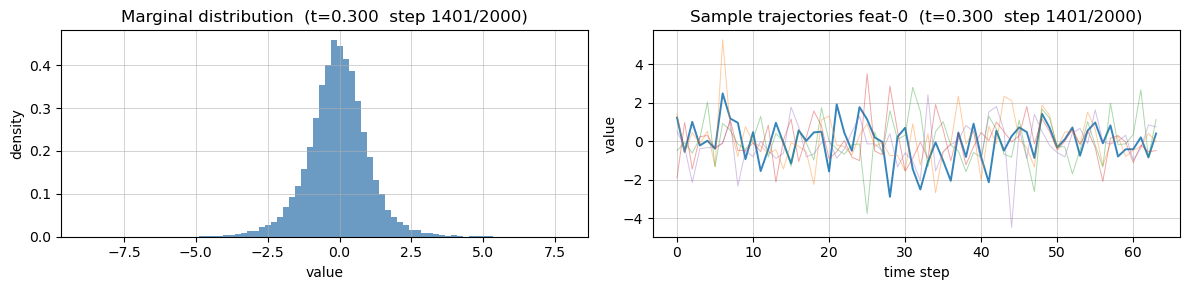

[step 1601/2000 | t=0.2004]  mean=-0.0643  std=1.0230  min=-8.3432  max=7.7914  dx_norm=1.34e-04
  skew=0.0268  kurt(excess)=2.7890
  per-feat std: k0=1.023
  elapsed 136.1s



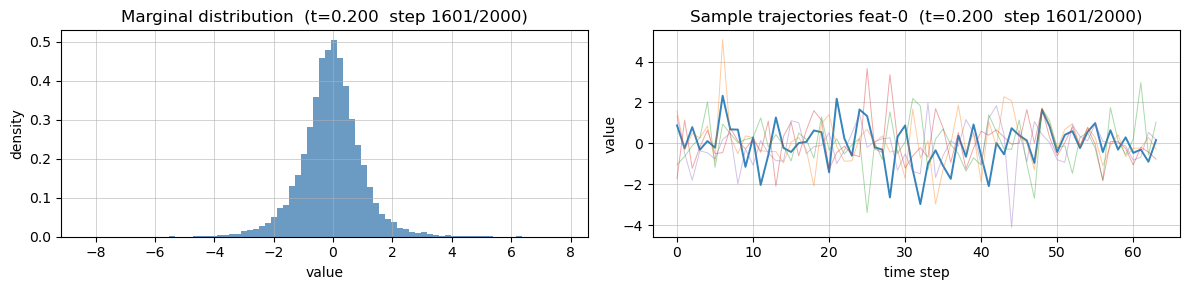

[step 1801/2000 | t=0.1005]  mean=-0.0651  std=1.0048  min=-8.0988  max=7.9114  dx_norm=8.38e-05
  skew=0.0525  kurt(excess)=3.0050
  per-feat std: k0=1.005
  elapsed 135.5s



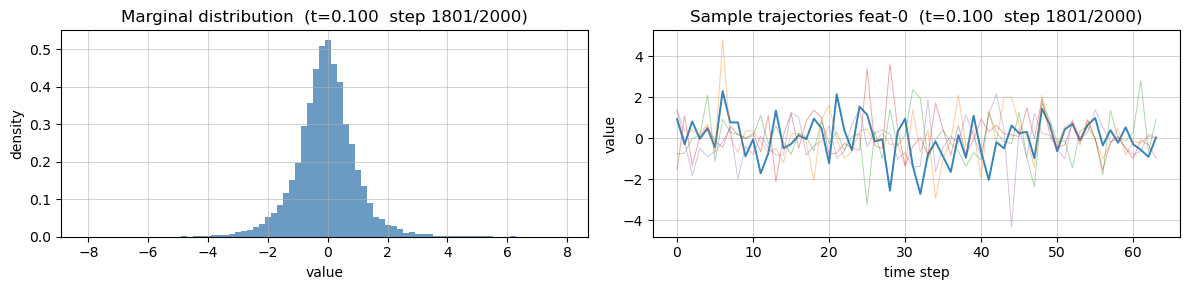

[step 1992/2000 | t=0.0050]  mean=-0.0675  std=0.9969  min=-7.9938  max=7.7993  dx_norm=5.36e-05
  skew=0.0559  kurt(excess)=3.0720
  per-feat std: k0=0.997
  elapsed 130.2s

[step 1993/2000 | t=0.0045]  mean=-0.0676  std=0.9969  min=-7.9996  max=7.8094  dx_norm=5.47e-05
  skew=0.0557  kurt(excess)=3.0736
  per-feat std: k0=0.997
  elapsed 0.7s

[step 1994/2000 | t=0.0040]  mean=-0.0676  std=0.9969  min=-7.9975  max=7.7936  dx_norm=5.39e-05
  skew=0.0555  kurt(excess)=3.0704
  per-feat std: k0=0.997
  elapsed 0.7s

[step 1995/2000 | t=0.0035]  mean=-0.0676  std=0.9969  min=-7.9963  max=7.7959  dx_norm=5.39e-05
  skew=0.0561  kurt(excess)=3.0720
  per-feat std: k0=0.997
  elapsed 0.7s

[step 1996/2000 | t=0.0030]  mean=-0.0677  std=0.9967  min=-7.9840  max=7.7939  dx_norm=5.42e-05
  skew=0.0563  kurt(excess)=3.0713
  per-feat std: k0=0.997
  elapsed 0.7s

[step 1997/2000 | t=0.0025]  mean=-0.0677  std=0.9967  min=-7.9843  max=7.8151  dx_norm=5.38e-05
  skew=0.0564  kurt(excess)=3.0746
 

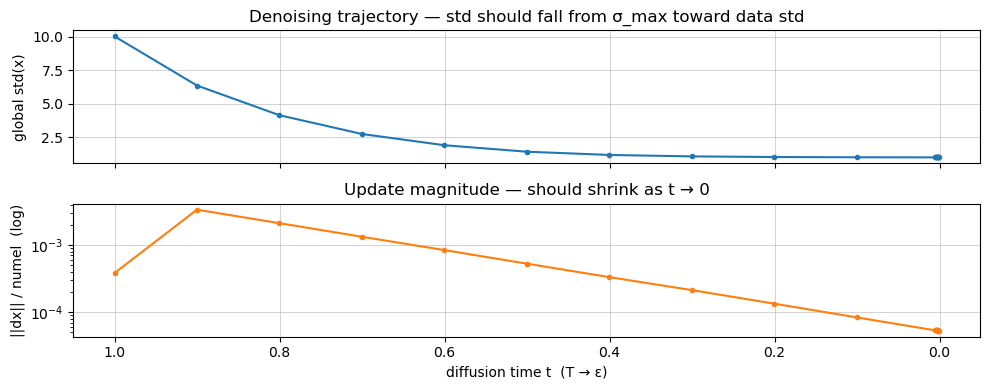

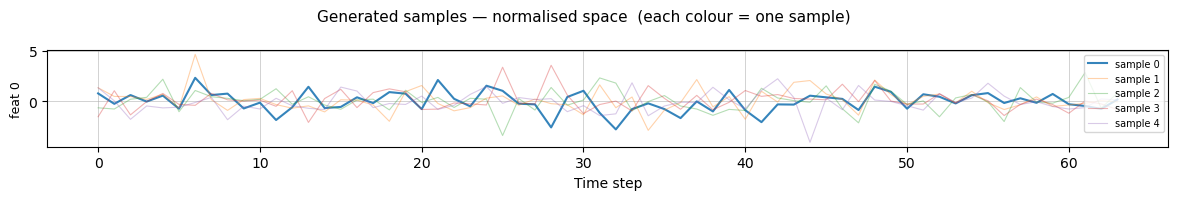

Generated 16,384 values  |  mean=-0.06776  std=0.99663


In [44]:
# Unconditional: zero observed data, zero conditioning mask
observed_data = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
cond_mask     = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
observed_tp   = torch.linspace(0.0, 1.0, seq_len, device=device)\
                     .unsqueeze(0).expand(N_SAMPLES, -1)

with torch.no_grad():
    samples = processes.reverse_process(
        model         = model,
        shape         = (N_SAMPLES, target_dim, seq_len),
        observed_data = observed_data,
        cond_mask     = cond_mask,
        observed_tp   = observed_tp,
        num_steps     = N_STEPS,
        device        = device,
    )

# Flatten to 1-D array of all generated values
gen_vals = samples.cpu().numpy().ravel()
print(f"Generated {len(gen_vals):,} values  |  "
      f"mean={gen_vals.mean():.5f}  std={gen_vals.std():.5f}")

## 3. Build reference distribution

In [49]:
rng = np.random.default_rng(SEED)
n_ref = len(gen_vals)

if REFERENCE_DISTRIBUTION == "gaussian":
    ref_vals = rng.normal(loc=0.0, scale=REF_STD, size=n_ref)
    ref_label = f"N(0, {REF_STD})"
    # scipy frozen distribution for QQ / PDF overlay
    ref_dist = scipy_stats.norm(loc=0.0, scale=REF_STD)

elif REFERENCE_DISTRIBUTION == "student_t":
    # Scale so Var = REF_STD^2  →  std = REF_STD * sqrt((df-2)/df)
    scale = REF_STD / np.sqrt(REF_DF / (REF_DF - 2))
    ref_vals = rng.standard_t(df=REF_DF, size=n_ref) * scale
    ref_label = f"t(df={REF_DF}, scale={scale:.4f})"
    ref_dist = scipy_stats.t(df=REF_DF, loc=0.0, scale=scale)

else:
    raise ValueError(f"Unknown REFERENCE_DISTRIBUTION: {REFERENCE_DISTRIBUTION!r}")

print(f"Reference ({ref_label}):  "
      f"mean={ref_vals.mean():.5f}  std={ref_vals.std():.5f}")

Reference (t(df=4, scale=0.7071)):  mean=-0.00481  std=0.99112


## 4. Moment comparison table

In [46]:
import pandas as pd

def moments(x, label):
    return {
        "label"          : label,
        "mean"           : np.mean(x),
        "std"            : np.std(x),
        "skewness"       : scipy_stats.skew(x),
        "excess_kurtosis": scipy_stats.kurtosis(x, fisher=True),
        "q01"            : np.quantile(x, 0.01),
        "q99"            : np.quantile(x, 0.99),
    }

df_moments = pd.DataFrame([moments(gen_vals, "Generated"),
                            moments(ref_vals, ref_label)])
df_moments = df_moments.set_index("label").round(6)

ks_stat, ks_p = scipy_stats.ks_2samp(gen_vals, ref_vals)
print(f"KS statistic = {ks_stat:.4f}  |  p-value = {ks_p:.4e}")
print()
display(df_moments)

KS statistic = 0.0341  |  p-value = 1.0861e-08



,mean,std,skewness,excess_kurtosis,q01,q99
label,,,,,,
Generated,-0.067758,0.996627,0.055240,3.074807,-2.767344,2.682163
"t(df=4, scale=0.7071)",-0.004813,0.991117,0.141166,7.724075,-2.651486,2.648764


## 5. Plots

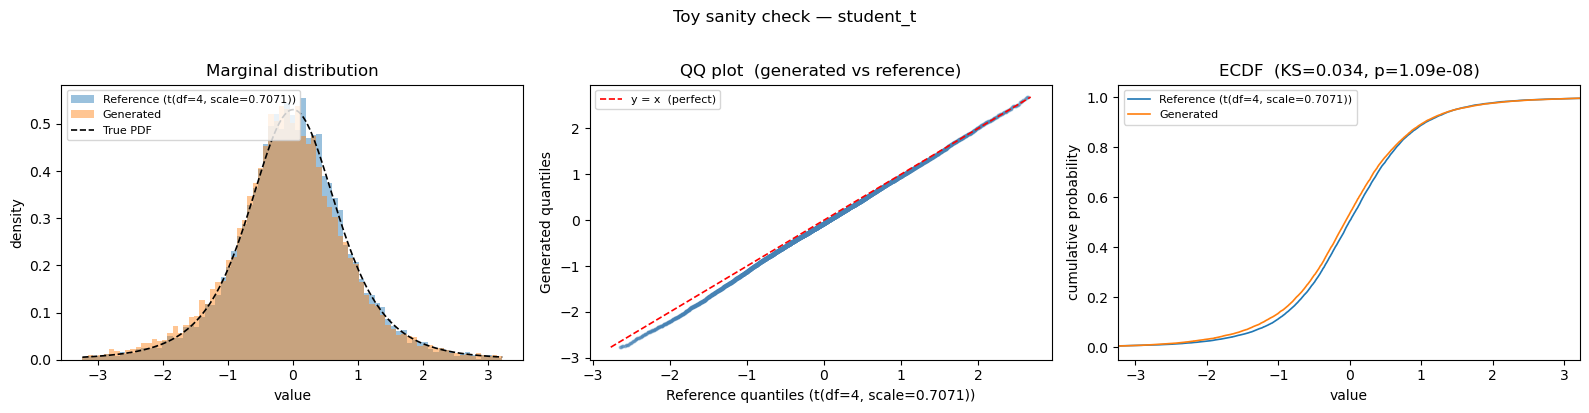

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── (a) Histogram + theoretical PDF ─────────────────────────────────────────
ax = axes[0]
combined = np.concatenate([gen_vals, ref_vals])
lo, hi   = np.quantile(combined, [0.005, 0.995])
bins     = np.linspace(lo, hi, 80)

ax.hist(ref_vals,  bins=bins, density=True, alpha=0.45, label=f"Reference ({ref_label})")
ax.hist(gen_vals,  bins=bins, density=True, alpha=0.45, label="Generated")
xs = np.linspace(lo, hi, 400)
ax.plot(xs, ref_dist.pdf(xs), "k--", linewidth=1.2, label="True PDF")
ax.set_title("Marginal distribution")
ax.set_xlabel("value"); ax.set_ylabel("density")
ax.legend(fontsize=8)

# ── (b) QQ plot of generated vs reference ───────────────────────────────────
ax = axes[1]
n_qq  = min(len(gen_vals), len(ref_vals), 5_000)
probs = np.linspace(0.01, 0.99, n_qq)
q_ref = ref_dist.ppf(probs)
q_gen = np.quantile(gen_vals, probs)

ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x  (perfect)")
ax.set_title("QQ plot  (generated vs reference)")
ax.set_xlabel(f"Reference quantiles ({ref_label})")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# ── (c) ECDF comparison ──────────────────────────────────────────────────────
ax = axes[2]
for vals, label, color in [(ref_vals, f"Reference ({ref_label})", "tab:blue"),
                            (gen_vals, "Generated", "tab:orange")]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF  (KS={ks_stat:.3f}, p={ks_p:.2e})")
ax.set_xlabel("value"); ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle(f"Toy sanity check — {REFERENCE_DISTRIBUTION}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6. What to look for

| Plot | Passing | Failing |
|------|---------|---------|
| Histogram | Generated bar heights track reference PDF closely | Wrong scale, shifted mean, or heavy/light tails |
| QQ plot | Points lie on the `y=x` diagonal | S-curve (tail mismatch), lateral shift (mean off), slope ≠ 1 (std off) |
| ECDF | Two curves nearly coincide | Large vertical gap = high KS stat |

**KS p-value interpretation**: p > 0.05 means you cannot reject that the two samples come from the same distribution — a good sign. p < 0.001 means a clear mismatch.